In [9]:
import flux_calc_parallel
import flux_variables
import thermalsyn_v2 as MQ24

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.colors import Normalize, LogNorm
from matplotlib.cm import ScalarMappable
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap

In [10]:
# These below params should be altered to see the effects!
s = 1e5 # Effective range of magnetic field values B1/B0
a = 3.0 # Index for magnetic field probability distribution
delta = 1.0 # Index for explicit relation between post-shock number density and magnetic field strength

R = 1e16 # Undocumented... forward shock wave radius

T = 50 # Time (days) of observation in observer's frame
n0 = 1e3 # Nominal value for upstream number density
eps_e = 0.000001 # Fraction of local fluid energy in power-law electrons
eps_B = 0.1 # Fraction of local fluid energy in magnetic field
eps_T = 0.4 # Fraction of local fluid energy in thermal electrons
p = 3.0 # Power-law electron distribution index

BG = 0.01 # Shock proper velocity at R=R0 (the radius at which the maximum perpendicular 
          # extent of the shock is reached; see Figure 1 in FM25)
k = 0 # Power-law index for stratified density (Eq. 12 in FM25)
alpha = 0 # Power-law index for deceleration (Eq. 11 in FM25)

# These will flip flop, overlay both when altering the above
therm_el = False # If True---calculates thermal electron synchrotron flux
pl_el = True # If True---calculates power-law electron synchrotron flux

# These stay constant or are already known for a source
mu_u = 0.62 # Mean molecular weight; nominal value 0.62
mu_e = 1.18 # Mean molecular weight per electron; nominal value 1.18
d_L = 10**28 # Luminosity distance (cm)
nu_res = 500 # Frequency array length
z = 0 # Source redshift

nu_low, nu_high = 1e-2,1e19


# We set mu_u and mu_e to their defaults. 
# Event dependent info: d_L, T

# Things we could change but prob won't:
# eps_e, eps_T, k, alpha, s, delta

# Things we should def change (in accordance to Ross' advice):
# BG, n0, a, eps_B

In [11]:
def span_values(lo, hi, n=3, logspace=False):
    """
    Pick n values spanning [lo, hi].
    """
    if n == 1: return np.array([(lo + hi) / 2.0], dtype=float)

    elif logspace: return np.logspace(np.log10(lo), np.log10(hi), n)

    else: return np.linspace(lo, hi, n)

def compute_Lnu(params, therm_el, pl_el):
    nu = np.logspace(np.log10(params["nu_low"]), np.log10(params["nu_high"]), params["nu_res"])
    Lnu = flux_variables.L_ELOS_IHG(
        nu,
        params["s"], params["a"], params["delta"],
        params["T"], params["n0"], params["eps_e"], params["eps_B"], params["eps_T"], params["p"],
        params["mu_u"], params["mu_e"],
        params["BG"], params["alpha"], params["k"],
        params["d_L"], params["z"],
        therm_el=therm_el, pl_el=pl_el
    )
    return nu, Lnu

def compute_Lnu_R(params, therm_el, pl_el):
    nu = np.logspace(np.log10(params["nu_low"]), np.log10(params["nu_high"]), params["nu_res"])
    Lnu = flux_variables.LOS_IHG_Fitted_R(
        nu,
        params["s"], params["a"], params["delta"], params["R"],
        params["T"], params["n0"], params["eps_e"], params["eps_B"], params["eps_T"], params["p"],
        params["mu_u"], params["mu_e"],
        params["BG"], params["k"],
        params["d_L"], params["z"],
        therm_el=therm_el, pl_el=pl_el
    )
    return nu, Lnu

ranges = {
    "s":     (1.1, 1e7),
    "a":     (0, 6.0),
    "delta": (0.0, 3.0),
    "R":     (1e18, 1e20),
    "T":     (1.0, 300.0),
    "n0":    (1e-2, 1e8),
    "eps_e": (1e-10, 1e-1),
    "eps_B": (1e-6,  1.0),
    "eps_T": (1e-6,  1.0),
    "p":     (2.0, 4.0),
    "BG":    (0.01, 0.9),
    "k":     (0.0, 2.0),
    "alpha": (0.0, 3.0),
}

params_to_vary = list(ranges.keys())  # should be 12

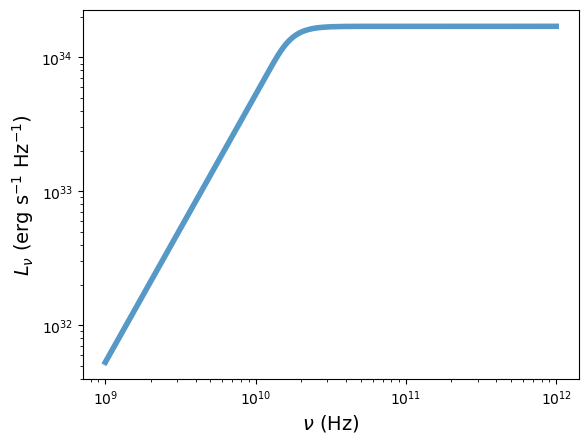

In [21]:
# s=1e5, a=3, delta=1
base = dict(
    s=1e5, a=3, delta=1.0, R=1e19,
    T=50, n0=1e3, eps_e=1e-6, eps_B=0.1, eps_T=0.4, p=3.0,
    BG=0.4, k=0.0, alpha=0.0,
    mu_u=0.62, mu_e=1.18, d_L=1e28, z=0.0,
    nu_res=500, nu_low=1e9, nu_high=1e12,
)
nu, Lnu = compute_Lnu_R(base, therm_el=True, pl_el=True)
plt.loglog(
    nu, Lnu,
    lw=4,
    alpha=0.75
)

plt.xlabel(r"$\nu$ (Hz)", fontsize=14)
plt.ylabel(r"$L_\nu$ (erg s$^{-1}$ Hz$^{-1}$)", fontsize=14)
plt.show()

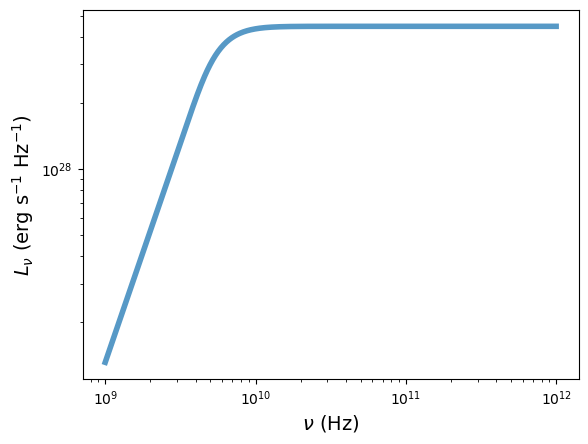

In [22]:
# s=1e5, a=3, delta=1
base = dict(
    s=1e5, a=3, delta=1.0,
    T=50, n0=1e3, eps_e=1e-6, eps_B=0.1, eps_T=0.4, p=3.0,
    BG=0.4, k=0.0, alpha=0.0,
    mu_u=0.62, mu_e=1.18, d_L=1e28, z=0.0,
    nu_res=500, nu_low=1e9, nu_high=1e12,
)
nu, Lnu = compute_Lnu(base, therm_el=True, pl_el=True)
plt.loglog(
    nu, Lnu,
    lw=4,
    alpha=0.75
)

plt.xlabel(r"$\nu$ (Hz)", fontsize=14)
plt.ylabel(r"$L_\nu$ (erg s$^{-1}$ Hz$^{-1}$)", fontsize=14)
plt.show()

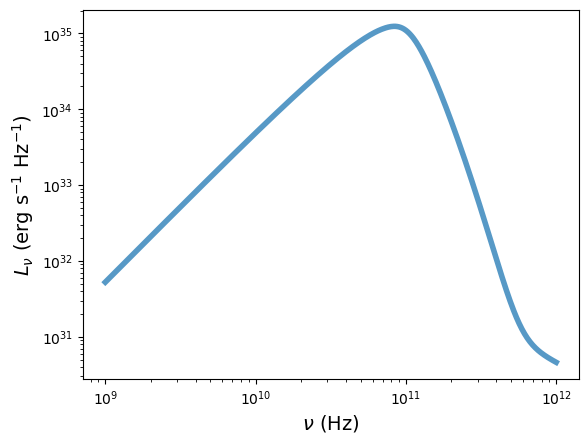

In [23]:
# s=1e5, a=0, delta=1
base = dict(
    s=1e5, a=0, delta=1.0, R=1e19,
    T=50, n0=1e3, eps_e=1e-6, eps_B=0.1, eps_T=0.4, p=3.0,
    BG=0.4, k=0.0, alpha=0.0,
    mu_u=0.62, mu_e=1.18, d_L=1e28, z=0.0,
    nu_res=500, nu_low=1e9, nu_high=1e12,
)

nu, Lnu = compute_Lnu_R(base, therm_el=True, pl_el=True)
plt.loglog(
    nu, Lnu,
    lw=4,
    alpha=0.75
)

plt.xlabel(r"$\nu$ (Hz)", fontsize=14)
plt.ylabel(r"$L_\nu$ (erg s$^{-1}$ Hz$^{-1}$)", fontsize=14)
plt.show()

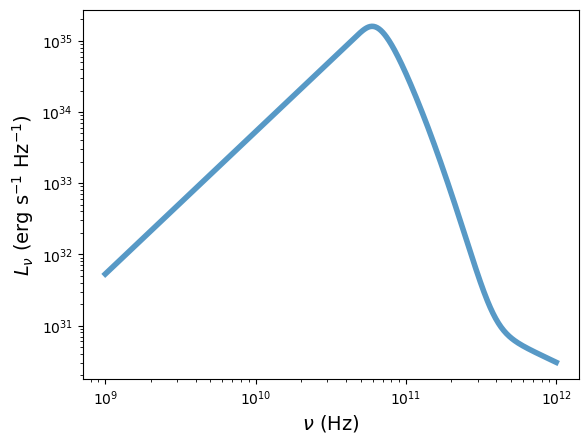

In [25]:
# s=1.1, a=3, delta=1
base = dict(
    s=1.1, a=3, delta=1.0, R=1e19,
    T=50, n0=1e3, eps_e=1e-6, eps_B=0.1, eps_T=0.4, p=3.0,
    BG=0.4, k=0.0, alpha=0.0,
    mu_u=0.62, mu_e=1.18, d_L=1e28, z=0.0,
    nu_res=500, nu_low=1e9, nu_high=1e12,
)
nu, Lnu = compute_Lnu_R(base, therm_el=True, pl_el=True)
plt.loglog(
    nu, Lnu,
    lw=4,
    alpha=0.75
)

plt.xlabel(r"$\nu$ (Hz)", fontsize=14)
plt.ylabel(r"$L_\nu$ (erg s$^{-1}$ Hz$^{-1}$)", fontsize=14)
plt.show()

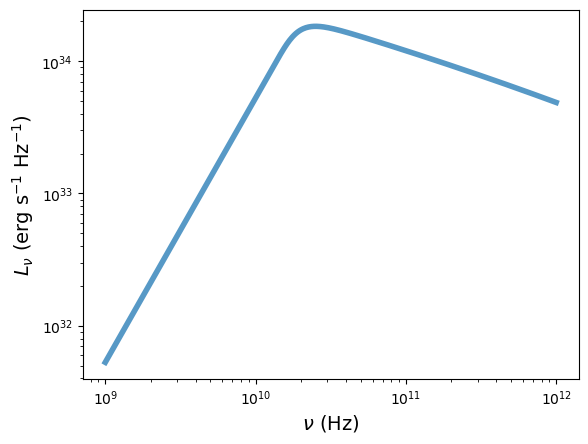

In [17]:
# s=1e5, a=3, delta=0
base = dict(
    s=1e5, a=3, delta=0, R=1e19,
    T=50, n0=1e3, eps_e=1e-6, eps_B=0.1, eps_T=0.4, p=3.0,
    BG=0.4, k=0.0, alpha=0.0,
    mu_u=0.62, mu_e=1.18, d_L=1e28, z=0.0,
    nu_res=500, nu_low=1e9, nu_high=1e12,
)

nu, Lnu = compute_Lnu_R(base, therm_el=True, pl_el=True)
plt.loglog(
    nu, Lnu,
    lw=4,
    alpha=0.75
)

plt.xlabel(r"$\nu$ (Hz)", fontsize=14)
plt.ylabel(r"$L_\nu$ (erg s$^{-1}$ Hz$^{-1}$)", fontsize=14)
plt.show()

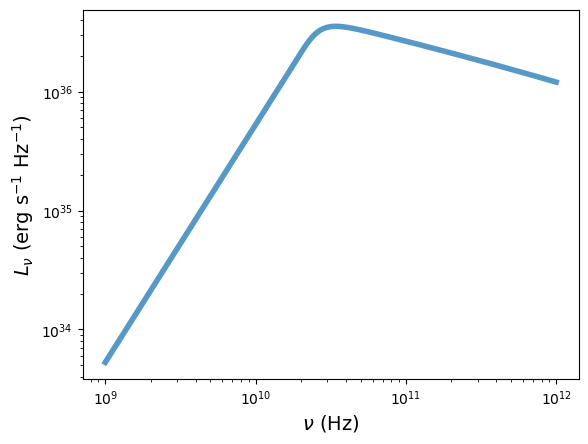

In [26]:
# s=1e5, a=3, delta=0
base = dict(
    s=1e5, a=3, delta=0, R=1e20,
    T=50, n0=1e3, eps_e=1e-6, eps_B=0.1, eps_T=0.4, p=3.0,
    BG=0.4, k=0.0, alpha=0.0,
    mu_u=0.62, mu_e=1.18, d_L=1e28, z=0.0,
    nu_res=500, nu_low=1e9, nu_high=1e12,
)

nu, Lnu = compute_Lnu_R(base, therm_el=True, pl_el=True)
plt.loglog(
    nu, Lnu,
    lw=4,
    alpha=0.75
)

plt.xlabel(r"$\nu$ (Hz)", fontsize=14)
plt.ylabel(r"$L_\nu$ (erg s$^{-1}$ Hz$^{-1}$)", fontsize=14)
plt.show()

In [27]:
 def plot_param_sweep(param_name, lo, hi, nvals=3): # max 7 nvals please

    colors = ["red", "orange", "yellow", "green", "blue", "indigo", "violet"]
    vals = span_values(lo, hi, n=nvals)

    for ii, v in enumerate(vals):
        p = base.copy()
        p[param_name] = v

        nu, Lnu = compute_Lnu_R(p, therm_el=True, pl_el=False)

        plt.loglog(
            nu, Lnu,
            color=colors[ii],
            lw=4,
            alpha=0.75,
            label=f"{param_name} = {v:g}"
        )

    plt.title(f"Vary {param_name}: [{lo}, {hi}]", fontsize=14)
    plt.xlabel(r"$\nu$ (Hz)", fontsize=14)
    plt.ylabel(r"$L_\nu$ (erg s$^{-1}$ Hz$^{-1}$)", fontsize=14)
    plt.legend()
    plt.show()

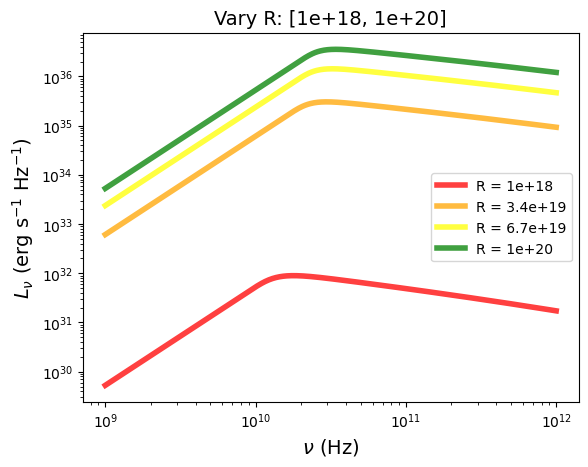

In [30]:
plot_param_sweep("R", 1e18, 1e20, nvals=4)

In [33]:
def plot_param_sweep_ax(ax, param_name, lo, hi, nvals=3, therm_el=True, pl_el=False, default=True):

    colors = ["red", "orange", "yellow", "green", "blue", "indigo", "violet"]
    logParams = ["s", "R", "n0", "eps_e", "eps_B", "eps_B"]
    if param_name in logParams: log = True
    else: log = False
    vals = span_values(lo, hi, n=nvals, logspace=log)

    for ii, v in enumerate(vals):
        p = base.copy()
        p[param_name] = v
        try:
            if default: nu, Lnu = compute_Lnu(p, therm_el=therm_el, pl_el=pl_el)
            else: nu, Lnu = compute_Lnu_R(p, therm_el=therm_el, pl_el=pl_el)
        except ZeroDivisionError:
            print(f'{param_name}={v:g} causes an error')
            continue
        ax.loglog(nu, Lnu, lw=2.5, alpha=0.75, color=colors[ii], label=f"{param_name} = {v:g}")

    ax.legend()
    ax.set_title(f"{param_name}", fontsize=11)
    ax.set_xlabel(r"$\nu$ (Hz)", fontsize=10)
    ax.set_ylabel(r"$L_\nu$ (erg s$^{-1}$ Hz$^{-1}$)", fontsize=10)

def plot_collage(param_names, ranges, nvals=3, therm_el=True, pl_el=False, default=True):

    fig, axes = plt.subplots(4, 3, figsize=(16,12), constrained_layout=True)
    axes = axes.ravel()

    for i, param_name in enumerate(params_to_vary):
        lo, hi = ranges[param_name]
        plot_param_sweep_ax(
            axes[i], param_name, lo, hi,
            nvals=nvals,
            therm_el=therm_el, pl_el=pl_el,
            default=default
        )

    return fig, axes

param_names = list(ranges.keys())

/Users/michaelcamilo/research/project_Thermal/thermal_synchrotron_v2/thermalsyn_v2.py:161: RuntimeWarning: divide by zero encountered in scalar divide
  return 2.0*Theta**2/special.kn(2,1.0/Theta)
/Users/michaelcamilo/research/project_Thermal/thermal_synchrotron_v2/thermalsyn_v2.py:566: RuntimeWarning: invalid value encountered in multiply
  val = (3.0**0.5/(8.0*np.pi))*(C.q**3/(C.me*C.c**2))*f_fun(Theta)*n*B*x*I_of_x(x)
/Users/michaelcamilo/research/project_Thermal/thermal_synchrotron_v2/thermalsyn_v2.py:596: RuntimeWarning: invalid value encountered in multiply
  val = (np.pi*3.0**(-3.0/2.0))*C.q*(n/(Theta**5*B))*f_fun(Theta)*x**(-1.0)*I_of_x(x)
/Users/michaelcamilo/research/project_Thermal/thermal_synchrotron_v2/flux_variables.py:1773: RuntimeWarning: invalid value encountered in divide
  L_vals = 4*np.pi**2*(R**2)*((D_val**3)/gamma**2)*(j/alp)*(1-np.exp(-tau))
/Users/michaelcamilo/research/project_Thermal/thermal_synchrotron_v2/thermalsyn_v2.py:301: RuntimeWarning: invalid value en

k=3 causes an error


/Users/michaelcamilo/research/project_Thermal/thermal_synchrotron_v2/flux_variables.py:406: RuntimeWarning: divide by zero encountered in scalar divide
  return (1-3/(4*(3-k)*(gamma_fluid(y,xi,Shell.t(y,T,R_l,z),t_test, R_test, bG_sh0,k,alpha,z,R0,R_l,X_perp,T,n0,GRB_convention=GRB_convention))**2))**(1/3)
/Users/michaelcamilo/research/project_Thermal/thermal_synchrotron_v2/flux_variables.py:1732: RuntimeWarning: divide by zero encountered in log10
  B_vals = np.logspace(np.log10(B0),np.log10(B1),B_res)
/Users/michaelcamilo/anaconda3/envs/R/lib/python3.13/site-packages/numpy/_core/function_base.py:139: RuntimeWarning: invalid value encountered in subtract
  delta = np.subtract(stop, start, dtype=type(dt))
/Users/michaelcamilo/research/project_Thermal/thermal_synchrotron_v2/flux_variables.py:1737: RuntimeWarning: divide by zero encountered in scalar power
  else:    A = (1-a)/(B1**(1-a) - B0**(1-a))
/Users/michaelcamilo/research/project_Thermal/thermal_synchrotron_v2/flux_variables.py:1

IndexError: index 12 is out of bounds for axis 0 with size 12

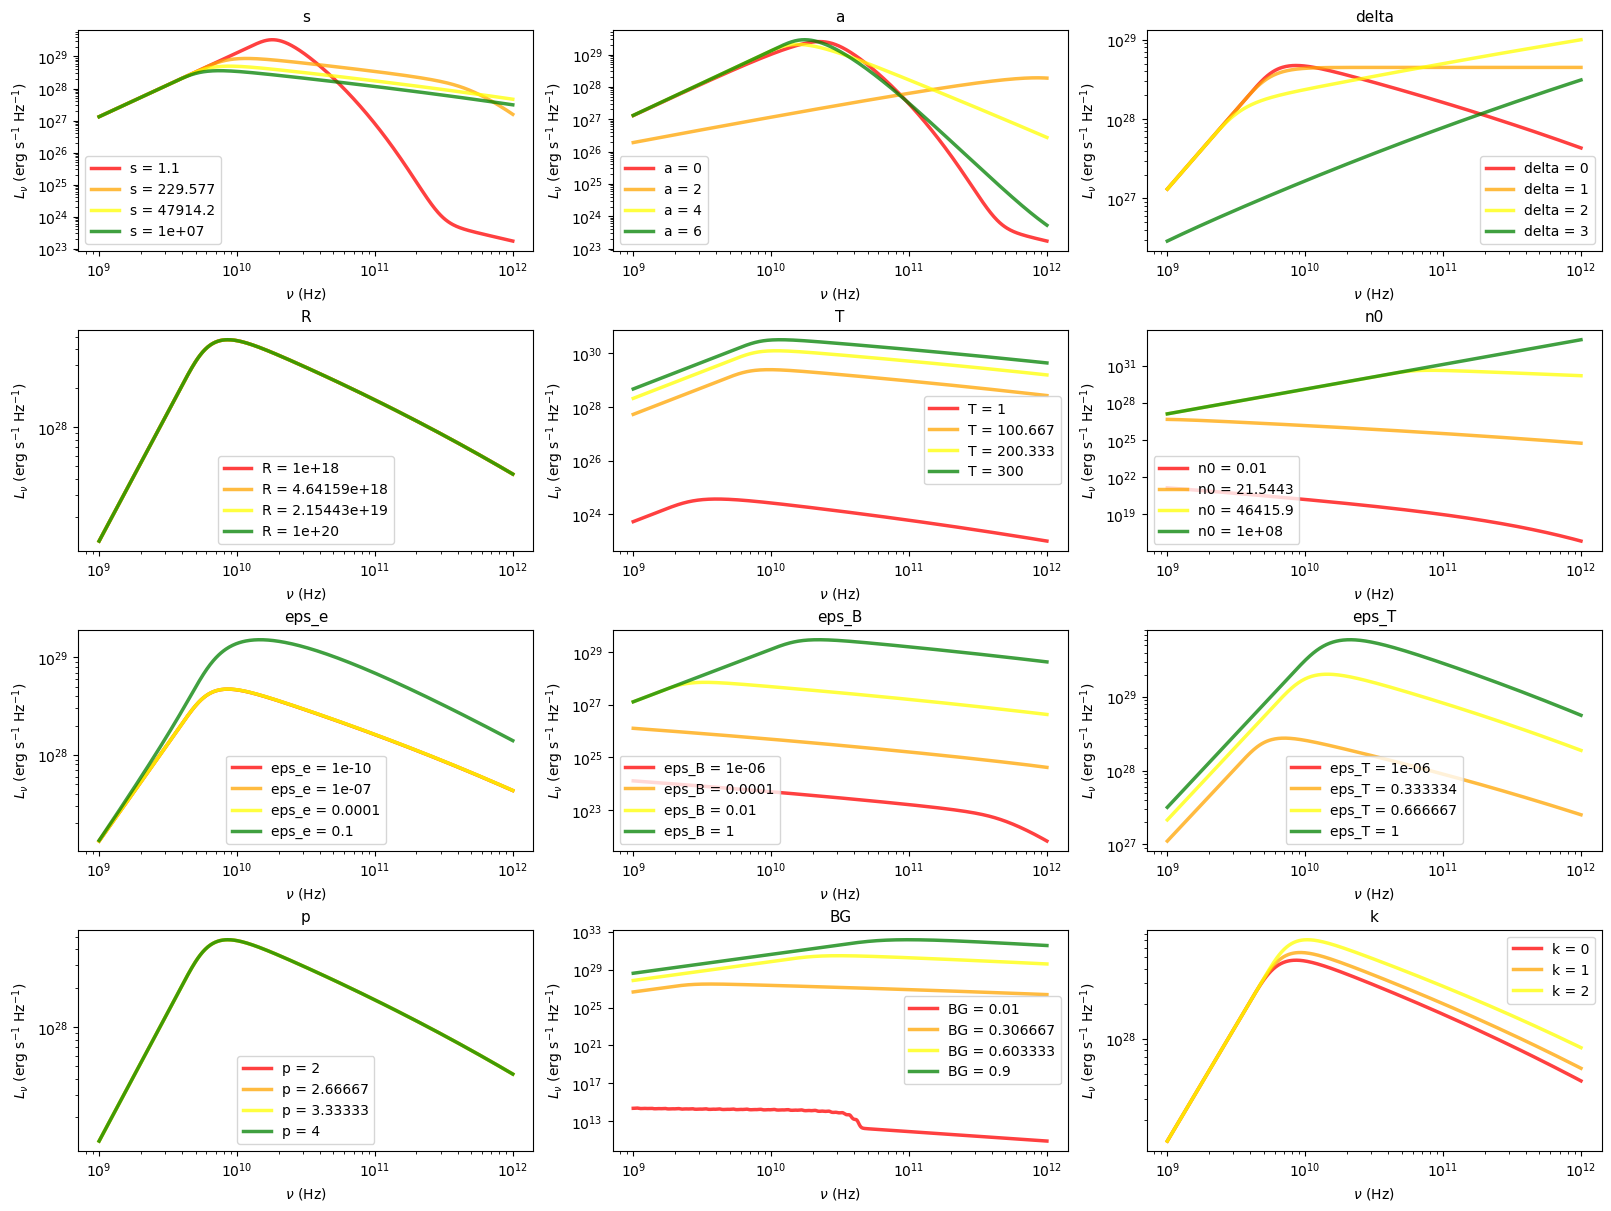

In [34]:
fig, axes = plot_collage(param_names, ranges, nvals=4, therm_el=True, pl_el=False, default=True)
plt.show()

In [ ]:
fig, axes = plot_collage(param_names, ranges, nvals=4, therm_el=True, pl_el=False, default=False)
plt.show()